# **1. LIBRARY IMPORTING**

In [1]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix
from scipy.spatial.distance import directed_hausdorff
from keras.saving import load_model
from keras.losses import BinaryCrossentropy
from IPython.display import display, Markdown

# **2. DATASETS AND METRICS**

## **2.1. Datasets**

In [2]:
img_size = 128

In [3]:
cxrs = np.load('/kaggle/input/lung-segmentation-dataset-ch0/without_convexhull/cxrs')
masks_ch0 = np.load('/kaggle/input/lung-segmentation-dataset-ch0/without_convexhull/masks')
masks_ch1 = np.load('/kaggle/input/lung-segmentation-dataset-ch0/with_convexhull/masks')
print(np.shape(cxrs))
print(np.shape(masks_ch0))
print(np.shape(masks_ch1))

(704, 128, 128)
(704, 128, 128)
(704, 128, 128)


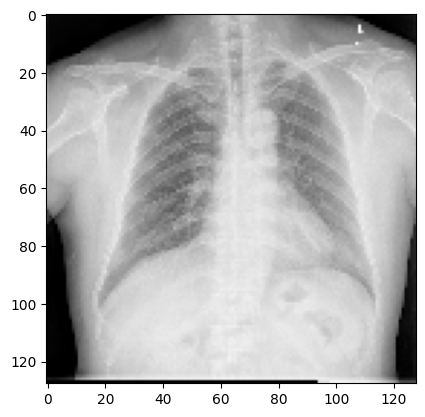

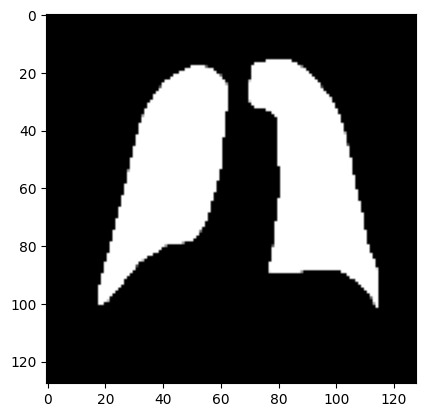

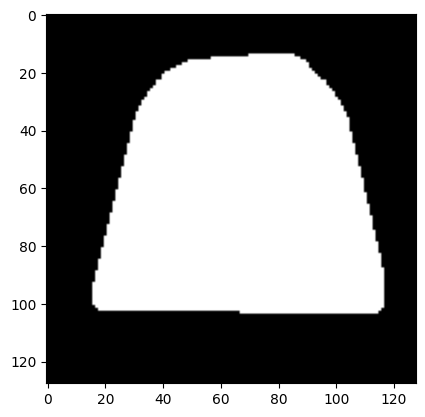

In [4]:
idx = 0
plt.imshow(cxrs[idx], cmap='gray')
plt.show()
plt.imshow(masks_ch0[idx], cmap='gray')
plt.show()
plt.imshow(masks_ch1[idx], cmap='gray')
plt.show()

In [5]:
cxrs = np.array(cxrs / 255)
masks_ch0 = np.array(masks_ch0 / 255)
masks_ch1 = np.array(masks_ch1 / 255)

## **2.2. Metrics**

In [6]:
def bce_loss(y_true, y_pred):
    epsilon = 1e-9
    bce = -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))
    return bce

In [7]:
def mean_dice(y_true, y_pred):
    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred >= 0.5, dtype=int)
    dice_list = []
    for i in range(np.shape(cxrs)[0]):
        intersection = np.sum(y_true[i] & y_pred[i])
        combination = np.sum(y_true[i]) + np.sum(y_pred[i])
        dice = intersection * 2 / combination
        dice_list.append(dice)
    return np.mean(dice_list), np.std(dice_list)

In [8]:
def mean_iou(y_true, y_pred):
    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred >= 0.5, dtype=int)
    iou_list = []
    for i in range(np.shape(cxrs)[0]):
        intersection = np.sum(y_true[i] & y_pred[i])
        union = np.sum(y_true[i] | y_pred[i])
        iou = intersection / union
        iou_list.append(iou)
    return np.mean(iou_list), np.std(iou_list)

In [9]:
def mean_hd(y_true, y_pred):
    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred >= 0.5, dtype=int)
    hd_list = []
    for i in range(np.shape(cxrs)[0]):
        points_true = np.argwhere(y_true[i] > 0)
        points_pred = np.argwhere(y_pred[i] > 0)
        hd = max(directed_hausdorff(points_true, points_pred)[0], directed_hausdorff(points_pred, points_true)[0])
        hd_list.append(hd)
    return np.mean(hd_list), np.std(hd_list)

In [10]:
def mean_accuracy(y_true, y_pred):
    y_true = np.array(y_true.reshape(np.shape(cxrs)[0], -1), dtype=int)
    y_pred = np.array(y_pred.reshape(np.shape(cxrs)[0], -1) >= 0.5, dtype=int)
    accuracy_list = []
    for i in range(np.shape(cxrs)[0]):
        accuracy = accuracy_score(y_true[i], y_pred[i])
        accuracy_list.append(accuracy)
    return np.mean(accuracy_list), np.std(accuracy_list)

In [11]:
def mean_precision(y_true, y_pred):
    y_true = np.array(y_true.reshape(np.shape(cxrs)[0], -1), dtype=int)
    y_pred = np.array(y_pred.reshape(np.shape(cxrs)[0], -1) >= 0.5, dtype=int)
    precision_list = []
    for i in range(np.shape(cxrs)[0]):
        precision = precision_score(y_true[i], y_pred[i])
        precision_list.append(precision)
    return np.mean(precision_list), np.std(precision_list)

In [12]:
def mean_recall(y_true, y_pred):
    y_true = np.array(y_true.reshape(np.shape(cxrs)[0], -1), dtype=int)
    y_pred = np.array(y_pred.reshape(np.shape(cxrs)[0], -1) >= 0.5, dtype=int)
    recall_list = []
    for i in range(np.shape(cxrs)[0]):
        recall = recall_score(y_true[i], y_pred[i])
        recall_list.append(recall)
    return np.mean(recall_list), np.std(recall_list)

In [13]:
def mean_f1score(y_true, y_pred):
    y_true = np.array(y_true.reshape(np.shape(cxrs)[0], -1), dtype=int)
    y_pred = np.array(y_pred.reshape(np.shape(cxrs)[0], -1) >= 0.5, dtype=int)
    f1score_list = []
    for i in range(np.shape(cxrs)[0]):
        f1score = f1_score(y_true[i], y_pred[i])
        f1score_list.append(f1score)
    return np.mean(f1score_list), np.std(f1score_list)

In [14]:
def mean_specificity(y_true, y_pred):
    y_true = np.array(y_true.reshape(np.shape(cxrs)[0], -1), dtype=int)
    y_pred = np.array(y_pred.reshape(np.shape(cxrs)[0], -1) >= 0.5, dtype=int)
    specificity_list = []
    for i in range(np.shape(cxrs)[0]):
        TN = np.sum((y_true[i] == 0) & (y_pred[i] == 0))
        FP = np.sum((y_true[i] == 0) & (y_pred[i] == 1))
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificity_list.append(specificity)
    return np.mean(specificity_list), np.std(specificity_list)

# **3. WITHOUT CONVEX HULL - UNET VARIANTS**

## **3.1. Models Loading**

In [15]:
unet_ch0 = load_model('/kaggle/input/unet/keras/default/6/Unet.h5')
# unet_ch0.summary()

history_train_loss_unet_ch0 = np.load('/kaggle/input/unet/keras/default/6/history_train_loss.npy')
history_val_loss_unet_ch0 = np.load('/kaggle/input/unet/keras/default/6/history_val_loss.npy')

In [16]:
attunet_ch0 = load_model('/kaggle/input/unet/keras/default/8/Attention-Unet.h5')
# attunet_ch0.summary()

history_train_loss_attunet_ch0 = np.load('/kaggle/input/unet/keras/default/8/history_train_loss.npy')
history_val_loss_attunet_ch0 = np.load('/kaggle/input/unet/keras/default/8/history_val_loss.npy')

In [17]:
unetpp_ch0 = load_model('/kaggle/input/unet/keras/default/9/Unet++.h5')
# unetpp_ch0.summary()

history_train_loss_unetpp_ch0 = np.load('/kaggle/input/unet/keras/default/9/history_train_loss.npy')
history_val_loss_unetpp_ch0 = np.load('/kaggle/input/unet/keras/default/9/history_val_loss.npy')

In [18]:
r2unet_ch0 = load_model('/kaggle/input/unet/keras/default/14/R2Unet.h5')
# r2unet_ch0.summary()

history_train_loss_r2unet_ch0 = np.load('/kaggle/input/unet/keras/default/14/history_train_loss.npy')
history_val_loss_r2unet_ch0 = np.load('/kaggle/input/unet/keras/default/14/history_val_loss.npy')

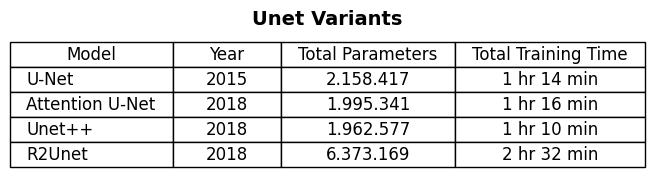

In [19]:
models = ['U-Net', 'Attention U-Net', 'Unet++', 'R2Unet']
years = [2015, 2018, 2018, 2018]
params = [unet_ch0.count_params(), attunet_ch0.count_params(), unetpp_ch0.count_params(), r2unet_ch0.count_params()]
times = ['1 hr 14 min', '1 hr 16 min', '1 hr 10 min', '2 hr 32 min']
formatted_params = [format(p, ',').replace(',', '.') for p in params]

df = pd.DataFrame({'Model': models, 'Year': years, 'Total Parameters': formatted_params, 'Total Training Time': times})

fig, ax = plt.subplots(figsize=(7, 1))
ax.axis("tight")
ax.axis("off")

ax.set_title('Unet Variants', fontsize=14, fontweight="bold", pad=30)
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc="center", loc="center", colWidths=[0.25, 0.2, 0.2, 0.2, 0.4])
table.scale(1.5, 1.5)

col_widths = [0.3, 0.2, 0.32, 0.35]
for i, width in enumerate(col_widths):
    for j in range(5):
        table[(j, i)].set_width(width)

table.auto_set_font_size(False)
table.set_fontsize(12)

for (i, j), cell in table._cells.items():
    if i == 0: 
        cell.set_text_props(ha="center")
    elif j == 0:
        cell.set_text_props(ha="left")
            
plt.show()

## **3.2. Performance of Unet Variants**

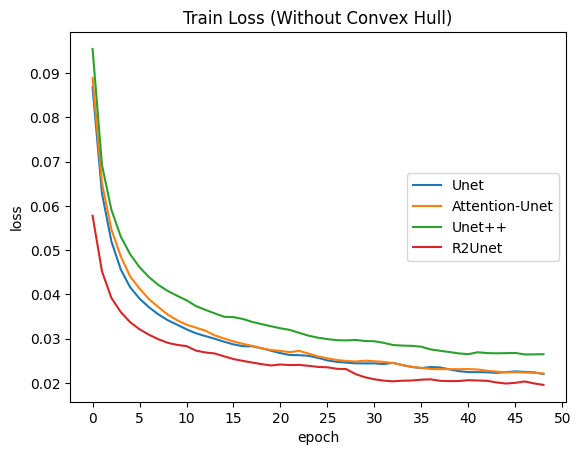

In [20]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_train_loss_unet_ch0[1:])
plt.plot(history_train_loss_attunet_ch0[1:])
plt.plot(history_train_loss_unetpp_ch0[1:])
plt.plot(history_train_loss_r2unet_ch0[1:])
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.xticks(x)
plt.title('Train Loss (Without Convex Hull)')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Unet', 'Attention-Unet', 'Unet++', 'R2Unet'], loc='center right')
plt.show()
plt.close()

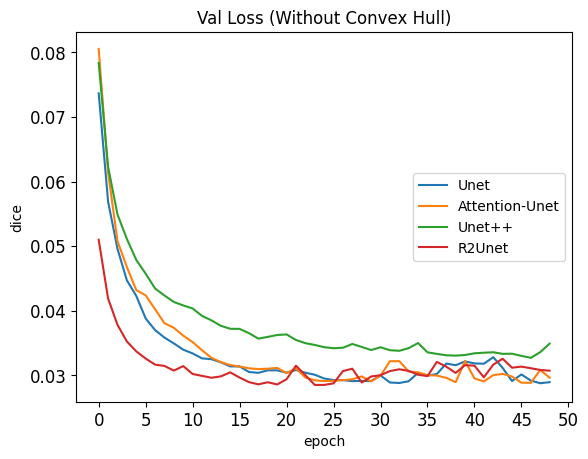

In [21]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_val_loss_unet_ch0[1:])
plt.plot(history_val_loss_attunet_ch0[1:])
plt.plot(history_val_loss_unetpp_ch0[1:])
plt.plot(history_val_loss_r2unet_ch0[1:])
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.xticks(x)
plt.title('Val Loss (Without Convex Hull)')
plt.ylabel('dice')
plt.xlabel('epoch')
plt.legend(['Unet', 'Attention-Unet', 'Unet++', 'R2Unet'], loc='center right')
plt.show()
plt.close()

In [22]:
masks_unet_ch0 = unet_ch0.predict(cxrs.reshape(-1, img_size, img_size, 1), verbose=True).reshape(-1, img_size, img_size)
masks_attunet_ch0 = attunet_ch0.predict(cxrs.reshape(-1, img_size, img_size, 1), verbose=True).reshape(-1, img_size, img_size)
masks_unetpp_ch0 = unetpp_ch0.predict(cxrs.reshape(-1, img_size, img_size, 1), verbose=True).reshape(-1, img_size, img_size)
masks_r2unet_ch0 = r2unet_ch0.predict(cxrs.reshape(-1, img_size, img_size, 1), verbose=True).reshape(-1, img_size, img_size)

print(np.shape(masks_unet_ch0))
print(np.shape(masks_attunet_ch0))
print(np.shape(masks_unetpp_ch0))
print(np.shape(masks_r2unet_ch0))

22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 934ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 858ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step
(704, 128, 128)
(704, 128, 128)
(704, 128, 128)
(704, 128, 128)


In [23]:
loss_unet_ch0 = bce_loss(masks_ch0, masks_unet_ch0)
dice_unet_ch0 = mean_dice(masks_ch0, masks_unet_ch0)
iou_unet_ch0 = mean_iou(masks_ch0, masks_unet_ch0)
hd_unet_ch0 = mean_hd(masks_ch0, masks_unet_ch0)

loss_attunet_ch0 = bce_loss(masks_ch0, masks_attunet_ch0)
dice_attunet_ch0 = mean_dice(masks_ch0, masks_attunet_ch0)
iou_attunet_ch0 = mean_iou(masks_ch0, masks_attunet_ch0)
hd_attunet_ch0 = mean_hd(masks_ch0, masks_attunet_ch0)

loss_unetpp_ch0 = bce_loss(masks_ch0, masks_unetpp_ch0)
dice_unetpp_ch0 = mean_dice(masks_ch0, masks_unetpp_ch0)
iou_unetpp_ch0 = mean_iou(masks_ch0, masks_unetpp_ch0)
hd_unetpp_ch0 = mean_hd(masks_ch0, masks_unetpp_ch0)

loss_r2unet_ch0 = bce_loss(masks_ch0, masks_r2unet_ch0)
dice_r2unet_ch0 = mean_dice(masks_ch0, masks_r2unet_ch0)
iou_r2unet_ch0 = mean_iou(masks_ch0, masks_r2unet_ch0)
hd_r2unet_ch0 = mean_hd(masks_ch0, masks_r2unet_ch0)

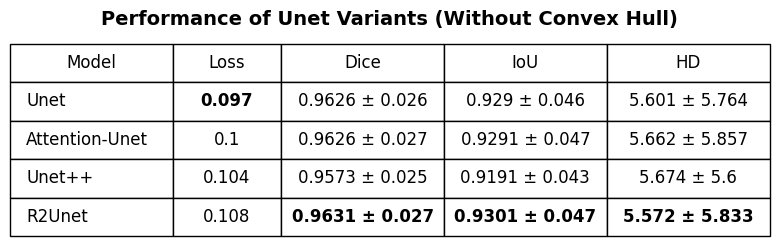

In [24]:
models = ['Unet', 'Attention-Unet', 'Unet++', 'R2Unet']

loss = []
loss.append(round(loss_unet_ch0, 3))
loss.append(round(loss_attunet_ch0, 3))
loss.append(round(loss_unetpp_ch0, 3))
loss.append(round(loss_r2unet_ch0, 3))

dice = []
dice.append(str(round(dice_unet_ch0[0], 4)) + ' ± ' + str(round(dice_unet_ch0[1], 3)))
dice.append(str(round(dice_attunet_ch0[0], 4)) + ' ± ' + str(round(dice_attunet_ch0[1], 3)))
dice.append(str(round(dice_unetpp_ch0[0], 4)) + ' ± ' + str(round(dice_unetpp_ch0[1], 3)))
dice.append(str(round(dice_r2unet_ch0[0], 4)) + ' ± ' + str(round(dice_r2unet_ch0[1], 3)))

iou = []
iou.append(str(round(iou_unet_ch0[0], 4)) + ' ± ' + str(round(iou_unet_ch0[1], 3)))
iou.append(str(round(iou_attunet_ch0[0], 4)) + ' ± ' + str(round(iou_attunet_ch0[1], 3)))
iou.append(str(round(iou_unetpp_ch0[0], 4)) + ' ± ' + str(round(iou_unetpp_ch0[1], 3)))
iou.append(str(round(iou_r2unet_ch0[0], 4)) + ' ± ' + str(round(iou_r2unet_ch0[1], 3)))

hd = []
hd.append(str(round(hd_unet_ch0[0], 3)) + ' ± ' + str(round(hd_unet_ch0[1], 3)))
hd.append(str(round(hd_attunet_ch0[0], 3)) + ' ± ' + str(round(hd_attunet_ch0[1], 3)))
hd.append(str(round(hd_unetpp_ch0[0], 3)) + ' ± ' + str(round(hd_unetpp_ch0[1], 3)))
hd.append(str(round(hd_r2unet_ch0[0], 3)) + ' ± ' + str(round(hd_r2unet_ch0[1], 3)))

df = pd.DataFrame({'Model': models, 'Loss': loss, 'Dice': dice, 'IoU': iou, 'HD': hd})

fig, ax = plt.subplots(figsize=(7, 1))
ax.axis("tight")
ax.axis("off")

ax.set_title('Performance of Unet Variants (Without Convex Hull)', fontsize=14, fontweight="bold", pad=55)
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc="center", loc="center", colWidths=[0.25, 0.2, 0.2, 0.2, 0.2])

col_widths = [0.3, 0.2, 0.3, 0.3, 0.3]
for i, width in enumerate(col_widths):
    for j in range(5):
        table[(j, i)].set_width(width)
        table[(j, i)].set_height(0.5)

for (i, j), cell in table._cells.items():
    if i == 0: 
        cell.set_text_props(ha="center")
    elif j == 0:
        cell.set_text_props(ha="left")
    elif j == 1:
        cell.set_text_props(ha="center")
        if i == 1:
            cell.set_text_props(weight="bold", color="black")
    elif j == 2:
        cell.set_text_props(ha="center")
        if i == 4:
            cell.set_text_props(weight="bold", color="black")
    elif j == 3:
        cell.set_text_props(ha="center")
        if i == 4:
            cell.set_text_props(weight="bold", color="black")
    elif j == 4:
        cell.set_text_props(ha="center")
        if i == 4:
            cell.set_text_props(weight="bold", color="black")

table.auto_set_font_size(False)
table.set_fontsize(12)
            
plt.show()

# **4. WITH CONVEX HULL - UNET VARIANTS**

## **4.1. Models Loading**

In [25]:
unet_ch1 = load_model('/kaggle/input/unet/keras/default/7/Unet.h5')
# unet_ch1.summary()

history_train_loss_unet_ch1 = np.load('/kaggle/input/unet/keras/default/7/history_train_loss.npy')
history_val_loss_unet_ch1 = np.load('/kaggle/input/unet/keras/default/7/history_val_loss.npy')

In [26]:
attunet_ch1 = load_model('/kaggle/input/unet/keras/default/16/Attention-Unet.h5')
# attunet_ch1.summary()

history_train_loss_attunet_ch1 = np.load('/kaggle/input/unet/keras/default/16/history_train_loss.npy')
history_val_loss_attunet_ch1 = np.load('/kaggle/input/unet/keras/default/16/history_val_loss.npy')

In [27]:
unetpp_ch1 = load_model('/kaggle/input/unet/keras/default/17/Unet++.h5')
# unetpp_ch1.summary()

history_train_loss_unetpp_ch1 = np.load('/kaggle/input/unet/keras/default/17/history_train_loss.npy')
history_val_loss_unetpp_ch1 = np.load('/kaggle/input/unet/keras/default/17/history_val_loss.npy')

In [28]:
r2unet_ch1 = load_model('/kaggle/input/unet/keras/default/15/R2Unet.h5')
# r2unet_ch1.summary()

history_train_loss_r2unet_ch1 = np.load('/kaggle/input/unet/keras/default/15/history_train_loss.npy')
history_val_loss_r2unet_ch1 = np.load('/kaggle/input/unet/keras/default/15/history_val_loss.npy')

## **4.2. Performance of Unet Variants**

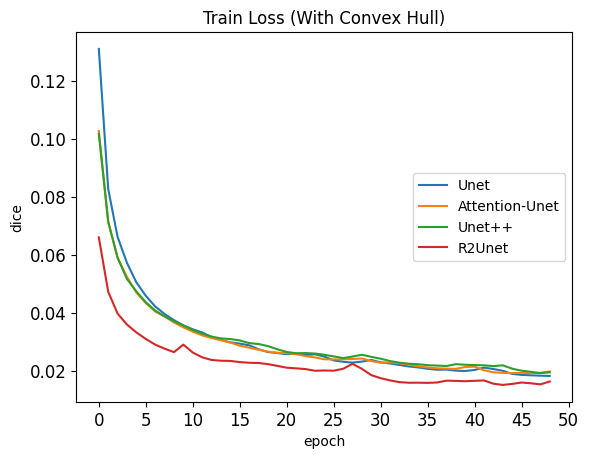

In [29]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_train_loss_unet_ch1[1:])
plt.plot(history_train_loss_attunet_ch1[1:])
plt.plot(history_train_loss_unetpp_ch1[1:])
plt.plot(history_train_loss_r2unet_ch1[1:])
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.xticks(x)
plt.title('Train Loss (With Convex Hull)')
plt.ylabel('dice')
plt.xlabel('epoch')
plt.legend(['Unet', 'Attention-Unet', 'Unet++', 'R2Unet'], loc='center right')
plt.show()
plt.close()

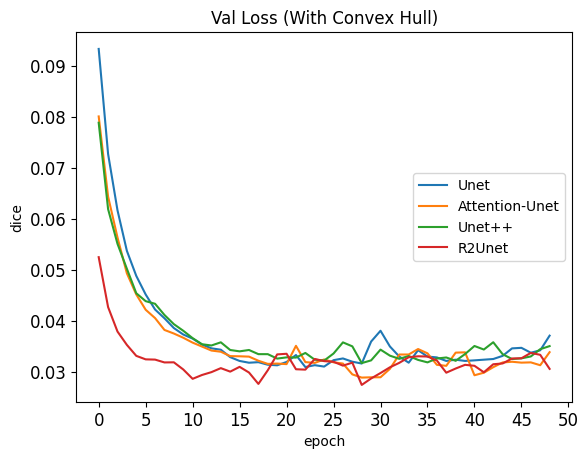

In [30]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_val_loss_unet_ch1[1:])
plt.plot(history_val_loss_attunet_ch1[1:])
plt.plot(history_val_loss_unetpp_ch1[1:])
plt.plot(history_val_loss_r2unet_ch1[1:])
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.xticks(x)
plt.title('Val Loss (With Convex Hull)')
plt.ylabel('dice')
plt.xlabel('epoch')
plt.legend(['Unet', 'Attention-Unet', 'Unet++', 'R2Unet'], loc='center right')
plt.show()
plt.close()

In [31]:
masks_unet_ch1 = unet_ch1.predict(cxrs.reshape(-1, img_size, img_size, 1), verbose=True).reshape(-1, img_size, img_size)
masks_attunet_ch1 = attunet_ch1.predict(cxrs.reshape(-1, img_size, img_size, 1), verbose=True).reshape(-1, img_size, img_size)
masks_unetpp_ch1 = unetpp_ch1.predict(cxrs.reshape(-1, img_size, img_size, 1), verbose=True).reshape(-1, img_size, img_size)
masks_r2unet_ch1 = r2unet_ch1.predict(cxrs.reshape(-1, img_size, img_size, 1), verbose=True).reshape(-1, img_size, img_size)

print(np.shape(masks_unet_ch1))
print(np.shape(masks_attunet_ch1))
print(np.shape(masks_unetpp_ch1))
print(np.shape(masks_r2unet_ch1))

22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 980ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 922ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 873ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step
(704, 128, 128)
(704, 128, 128)
(704, 128, 128)
(704, 128, 128)


In [32]:
loss_unet_ch1 = bce_loss(masks_ch1, masks_unet_ch1)
dice_unet_ch1 = mean_dice(masks_ch1, masks_unet_ch1)
iou_unet_ch1 = mean_iou(masks_ch1, masks_unet_ch1)
hd_unet_ch1 = mean_hd(masks_ch1, masks_unet_ch1)

loss_attunet_ch1 = bce_loss(masks_ch1, masks_attunet_ch1)
dice_attunet_ch1 = mean_dice(masks_ch1, masks_attunet_ch1)
iou_attunet_ch1 = mean_iou(masks_ch1, masks_attunet_ch1)
hd_attunet_ch1 = mean_hd(masks_ch1, masks_attunet_ch1)

loss_unetpp_ch1 = bce_loss(masks_ch1, masks_unetpp_ch1)
dice_unetpp_ch1 = mean_dice(masks_ch1, masks_unetpp_ch1)
iou_unetpp_ch1 = mean_iou(masks_ch1, masks_unetpp_ch1)
hd_unetpp_ch1 = mean_hd(masks_ch1, masks_unetpp_ch1)

loss_r2unet_ch1 = bce_loss(masks_ch1, masks_r2unet_ch1)
dice_r2unet_ch1 = mean_dice(masks_ch1, masks_r2unet_ch1)
iou_r2unet_ch1 = mean_iou(masks_ch1, masks_r2unet_ch1)
hd_r2unet_ch1 = mean_hd(masks_ch1, masks_r2unet_ch1)

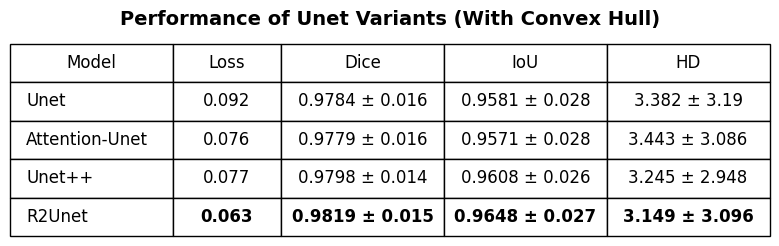

In [33]:
models = ['Unet', 'Attention-Unet', 'Unet++', 'R2Unet']

loss = []
loss.append(round(loss_unet_ch1, 3))
loss.append(round(loss_attunet_ch1, 3))
loss.append(round(loss_unetpp_ch1, 3))
loss.append(round(loss_r2unet_ch1, 3))

dice = []
dice.append(str(round(dice_unet_ch1[0], 4)) + ' ± ' + str(round(dice_unet_ch1[1], 3)))
dice.append(str(round(dice_attunet_ch1[0], 4)) + ' ± ' + str(round(dice_attunet_ch1[1], 3)))
dice.append(str(round(dice_unetpp_ch1[0], 4)) + ' ± ' + str(round(dice_unetpp_ch1[1], 3)))
dice.append(str(round(dice_r2unet_ch1[0], 4)) + ' ± ' + str(round(dice_r2unet_ch1[1], 3)))

iou = []
iou.append(str(round(iou_unet_ch1[0], 4)) + ' ± ' + str(round(iou_unet_ch1[1], 3)))
iou.append(str(round(iou_attunet_ch1[0], 4)) + ' ± ' + str(round(iou_attunet_ch1[1], 3)))
iou.append(str(round(iou_unetpp_ch1[0], 4)) + ' ± ' + str(round(iou_unetpp_ch1[1], 3)))
iou.append(str(round(iou_r2unet_ch1[0], 4)) + ' ± ' + str(round(iou_r2unet_ch1[1], 3)))

hd = []
hd.append(str(round(hd_unet_ch1[0], 3)) + ' ± ' + str(round(hd_unet_ch1[1], 3)))
hd.append(str(round(hd_attunet_ch1[0], 3)) + ' ± ' + str(round(hd_attunet_ch1[1], 3)))
hd.append(str(round(hd_unetpp_ch1[0], 3)) + ' ± ' + str(round(hd_unetpp_ch1[1], 3)))
hd.append(str(round(hd_r2unet_ch1[0], 3)) + ' ± ' + str(round(hd_r2unet_ch1[1], 3)))

df = pd.DataFrame({'Model': models, 'Loss': loss, 'Dice': dice, 'IoU': iou, 'HD': hd})

fig, ax = plt.subplots(figsize=(7, 1))
ax.axis("tight")
ax.axis("off")

ax.set_title('Performance of Unet Variants (With Convex Hull)', fontsize=14, fontweight="bold", pad=55)
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc="center", loc="center", colWidths=[0.25, 0.2, 0.2, 0.2, 0.2])

col_widths = [0.3, 0.2, 0.3, 0.3, 0.3]
for i, width in enumerate(col_widths):
    for j in range(5):
        table[(j, i)].set_width(width)
        table[(j, i)].set_height(0.5)

for (i, j), cell in table._cells.items():
    if i == 0: 
        cell.set_text_props(ha="center")
    elif j == 0:
        cell.set_text_props(ha="left")
    elif j == 1:
        cell.set_text_props(ha="center")
        if i == 4:
            cell.set_text_props(weight="bold", color="black")
    elif j == 2:
        cell.set_text_props(ha="center")
        if i == 4:
            cell.set_text_props(weight="bold", color="black")
    elif j == 3:
        cell.set_text_props(ha="center")
        if i == 4:
            cell.set_text_props(weight="bold", color="black")
    elif j == 4:
        cell.set_text_props(ha="center")
        if i == 4:
            cell.set_text_props(weight="bold", color="black")

table.auto_set_font_size(False)
table.set_fontsize(12)
            
plt.show()

# **5. WITH VS WITHOUT CONVEX HULL**

In [34]:
accuracy_unet_ch0 = mean_accuracy(masks_ch0, masks_unet_ch0)
precision_unet_ch0 = mean_precision(masks_ch0, masks_unet_ch0)
recall_unet_ch0 = mean_recall(masks_ch0, masks_unet_ch0)
f1score_unet_ch0 = mean_f1score(masks_ch0, masks_unet_ch0)
specificity_unet_ch0 = mean_specificity(masks_ch0, masks_unet_ch0)

accuracy_attunet_ch0 = mean_accuracy(masks_ch0, masks_attunet_ch0)
precision_attunet_ch0 = mean_precision(masks_ch0, masks_attunet_ch0)
recall_attunet_ch0 = mean_recall(masks_ch0, masks_attunet_ch0)
f1score_attunet_ch0 = mean_f1score(masks_ch0, masks_attunet_ch0)
specificity_attunet_ch0 = mean_specificity(masks_ch0, masks_attunet_ch0)

accuracy_unetpp_ch0 = mean_accuracy(masks_ch0, masks_unetpp_ch0)
precision_unetpp_ch0 = mean_precision(masks_ch0, masks_unetpp_ch0)
recall_unetpp_ch0 = mean_recall(masks_ch0, masks_unetpp_ch0)
f1score_unetpp_ch0 = mean_f1score(masks_ch0, masks_unetpp_ch0)
specificity_unetpp_ch0 = mean_specificity(masks_ch0, masks_unetpp_ch0)

accuracy_r2unet_ch0 = mean_accuracy(masks_ch0, masks_r2unet_ch0)
precision_r2unet_ch0 = mean_precision(masks_ch0, masks_r2unet_ch0)
recall_r2unet_ch0 = mean_recall(masks_ch0, masks_r2unet_ch0)
f1score_r2unet_ch0 = mean_f1score(masks_ch0, masks_r2unet_ch0)
specificity_r2unet_ch0 = mean_specificity(masks_ch0, masks_r2unet_ch0)

accuracy_unet_ch1 = mean_accuracy(masks_ch0, masks_unet_ch1)
precision_unet_ch1 = mean_precision(masks_ch0, masks_unet_ch1)
recall_unet_ch1 = mean_recall(masks_ch0, masks_unet_ch1)
f1score_unet_ch1 = mean_f1score(masks_ch0, masks_unet_ch1)
specificity_unet_ch1 = mean_specificity(masks_ch0, masks_unet_ch1)

accuracy_attunet_ch1 = mean_accuracy(masks_ch0, masks_attunet_ch1)
precision_attunet_ch1 = mean_precision(masks_ch0, masks_attunet_ch1)
recall_attunet_ch1 = mean_recall(masks_ch0, masks_attunet_ch1)
f1score_attunet_ch1 = mean_f1score(masks_ch0, masks_attunet_ch1)
specificity_attunet_ch1 = mean_specificity(masks_ch0, masks_attunet_ch1)

accuracy_unetpp_ch1 = mean_accuracy(masks_ch0, masks_unetpp_ch1)
precision_unetpp_ch1 = mean_precision(masks_ch0, masks_unetpp_ch1)
recall_unetpp_ch1 = mean_recall(masks_ch0, masks_unetpp_ch1)
f1score_unetpp_ch1 = mean_f1score(masks_ch0, masks_unetpp_ch1)
specificity_unetpp_ch1 = mean_specificity(masks_ch0, masks_unetpp_ch1)

accuracy_r2unet_ch1 = mean_accuracy(masks_ch0, masks_r2unet_ch1)
precision_r2unet_ch1 = mean_precision(masks_ch0, masks_r2unet_ch1)
recall_r2unet_ch1 = mean_recall(masks_ch0, masks_r2unet_ch1)
f1score_r2unet_ch1 = mean_f1score(masks_ch0, masks_r2unet_ch1)
specificity_r2unet_ch1 = mean_specificity(masks_ch0, masks_r2unet_ch1)

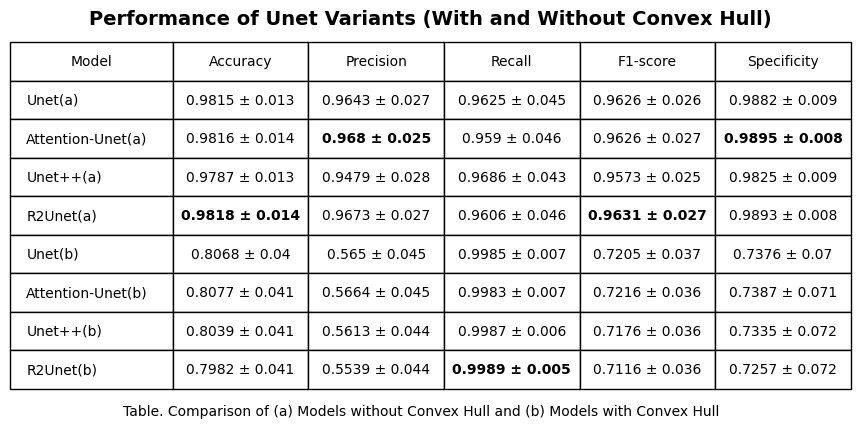

In [35]:
models = ['Unet(a)', 'Attention-Unet(a)', 'Unet++(a)', 'R2Unet(a)', 'Unet(b)', 'Attention-Unet(b)', 'Unet++(b)', 'R2Unet(b)']

accuracy = []
accuracy.append(str(round(accuracy_unet_ch0[0], 4)) + ' ± ' + str(round(accuracy_unet_ch0[1], 3)))
accuracy.append(str(round(accuracy_attunet_ch0[0], 4)) + ' ± ' + str(round(accuracy_attunet_ch0[1], 3)))
accuracy.append(str(round(accuracy_unetpp_ch0[0], 4)) + ' ± ' + str(round(accuracy_unetpp_ch0[1], 3)))
accuracy.append(str(round(accuracy_r2unet_ch0[0], 4)) + ' ± ' + str(round(accuracy_r2unet_ch0[1], 3)))
accuracy.append(str(round(accuracy_unet_ch1[0], 4)) + ' ± ' + str(round(accuracy_unet_ch1[1], 3)))
accuracy.append(str(round(accuracy_attunet_ch1[0], 4)) + ' ± ' + str(round(accuracy_attunet_ch1[1], 3)))
accuracy.append(str(round(accuracy_unetpp_ch1[0], 4)) + ' ± ' + str(round(accuracy_unetpp_ch1[1], 3)))
accuracy.append(str(round(accuracy_r2unet_ch1[0], 4)) + ' ± ' + str(round(accuracy_r2unet_ch1[1], 3)))

precision = []
precision.append(str(round(precision_unet_ch0[0], 4)) + ' ± ' + str(round(precision_unet_ch0[1], 3)))
precision.append(str(round(precision_attunet_ch0[0], 4)) + ' ± ' + str(round(precision_attunet_ch0[1], 3)))
precision.append(str(round(precision_unetpp_ch0[0], 4)) + ' ± ' + str(round(precision_unetpp_ch0[1], 3)))
precision.append(str(round(precision_r2unet_ch0[0], 4)) + ' ± ' + str(round(precision_r2unet_ch0[1], 3)))
precision.append(str(round(precision_unet_ch1[0], 4)) + ' ± ' + str(round(precision_unet_ch1[1], 3)))
precision.append(str(round(precision_attunet_ch1[0], 4)) + ' ± ' + str(round(precision_attunet_ch1[1], 3)))
precision.append(str(round(precision_unetpp_ch1[0], 4)) + ' ± ' + str(round(precision_unetpp_ch1[1], 3)))
precision.append(str(round(precision_r2unet_ch1[0], 4)) + ' ± ' + str(round(precision_r2unet_ch1[1], 3)))

recall = []
recall.append(str(round(recall_unet_ch0[0], 4)) + ' ± ' + str(round(recall_unet_ch0[1], 3)))
recall.append(str(round(recall_attunet_ch0[0], 4)) + ' ± ' + str(round(recall_attunet_ch0[1], 3)))
recall.append(str(round(recall_unetpp_ch0[0], 4)) + ' ± ' + str(round(recall_unetpp_ch0[1], 3)))
recall.append(str(round(recall_r2unet_ch0[0], 4)) + ' ± ' + str(round(recall_r2unet_ch0[1], 3)))
recall.append(str(round(recall_unet_ch1[0], 4)) + ' ± ' + str(round(recall_unet_ch1[1], 3)))
recall.append(str(round(recall_attunet_ch1[0], 4)) + ' ± ' + str(round(recall_attunet_ch1[1], 3)))
recall.append(str(round(recall_unetpp_ch1[0], 4)) + ' ± ' + str(round(recall_unetpp_ch1[1], 3)))
recall.append(str(round(recall_r2unet_ch1[0], 4)) + ' ± ' + str(round(recall_r2unet_ch1[1], 3)))

f1score = []
f1score.append(str(round(f1score_unet_ch0[0], 4)) + ' ± ' + str(round(f1score_unet_ch0[1], 3)))
f1score.append(str(round(f1score_attunet_ch0[0], 4)) + ' ± ' + str(round(f1score_attunet_ch0[1], 3)))
f1score.append(str(round(f1score_unetpp_ch0[0], 4)) + ' ± ' + str(round(f1score_unetpp_ch0[1], 3)))
f1score.append(str(round(f1score_r2unet_ch0[0], 4)) + ' ± ' + str(round(f1score_r2unet_ch0[1], 3)))
f1score.append(str(round(f1score_unet_ch1[0], 4)) + ' ± ' + str(round(f1score_unet_ch1[1], 3)))
f1score.append(str(round(f1score_attunet_ch1[0], 4)) + ' ± ' + str(round(f1score_attunet_ch1[1], 3)))
f1score.append(str(round(f1score_unetpp_ch1[0], 4)) + ' ± ' + str(round(f1score_unetpp_ch1[1], 3)))
f1score.append(str(round(f1score_r2unet_ch1[0], 4)) + ' ± ' + str(round(f1score_r2unet_ch1[1], 3)))

specificity = []
specificity.append(str(round(specificity_unet_ch0[0], 4)) + ' ± ' + str(round(specificity_unet_ch0[1], 3)))
specificity.append(str(round(specificity_attunet_ch0[0], 4)) + ' ± ' + str(round(specificity_attunet_ch0[1], 3)))
specificity.append(str(round(specificity_unetpp_ch0[0], 4)) + ' ± ' + str(round(specificity_unetpp_ch0[1], 3)))
specificity.append(str(round(specificity_r2unet_ch0[0], 4)) + ' ± ' + str(round(specificity_r2unet_ch0[1], 3)))
specificity.append(str(round(specificity_unet_ch1[0], 4)) + ' ± ' + str(round(specificity_unet_ch1[1], 3)))
specificity.append(str(round(specificity_attunet_ch1[0], 4)) + ' ± ' + str(round(specificity_attunet_ch1[1], 3)))
specificity.append(str(round(specificity_unetpp_ch1[0], 4)) + ' ± ' + str(round(specificity_unetpp_ch1[1], 3)))
specificity.append(str(round(specificity_r2unet_ch1[0], 4)) + ' ± ' + str(round(specificity_r2unet_ch1[1], 3)))

df = pd.DataFrame({'Model': models, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-score': f1score, 'Specificity': specificity})

fig, ax = plt.subplots(figsize=(7, 1))
ax.axis("tight")
ax.axis("off")

ax.set_title('Performance of Unet Variants (With and Without Convex Hull)', fontsize=14, fontweight="bold", pad=110)
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc="center", loc="center", colWidths=[0.25, 0.2, 0.2, 0.2, 0.2, 0.2])

col_widths = [0.3, 0.25, 0.25, 0.25, 0.25, 0.25]
for i, width in enumerate(col_widths):
    for j in range(9):
        table[(j, i)].set_width(width)
        table[(j, i)].set_height(0.5)

for (i, j), cell in table._cells.items():
    if i == 0: 
        cell.set_text_props(ha="center")
    elif j == 0:
        cell.set_text_props(ha="left")
    elif j == 1:
        cell.set_text_props(ha="center")
        if i == 4:
            cell.set_text_props(weight="bold", color="black")
    elif j == 2:
        cell.set_text_props(ha="center")
        if i == 2:
            cell.set_text_props(weight="bold", color="black")
    elif j == 3:
        cell.set_text_props(ha="center")
        if i == 8:
            cell.set_text_props(weight="bold", color="black")
    elif j == 4:
        cell.set_text_props(ha="center")
        if i == 4:
            cell.set_text_props(weight="bold", color="black")
    elif j == 5:
        cell.set_text_props(ha="center")
        if i == 2:
            cell.set_text_props(weight="bold", color="black")

table.auto_set_font_size(False)
table.set_fontsize(10)
            
plt.figtext(0.5, -1.5, "Table. Comparison of (a) Models without Convex Hull and (b) Models with Convex Hull", ha="center", fontsize=10)
plt.show()